<a href="https://colab.research.google.com/github/henrique819/tech_challenge_fase_3/blob/main/tech_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tech Challenge — PNAD-COVID19 (IBGE)
### Análise para planejamento hospitalar, com a base organizada no BigQuery

Roda **tudo no Colab, de ponta a ponta**: ingestão (IBGE) → ETL em **Spark** → carga no
**BigQuery** → análises por **SQL na nuvem** → gráficos. Todas as estimativas usam o
**peso amostral (V1032)**.

**Pré-requisito:** conta Google + um projeto no Google Cloud (o *BigQuery Sandbox*
funciona sem cartão). Você informa o ID do projeto no Passo 4.

## 1 — Clonar o repositório e instalar dependências

In [1]:
!rm -rf tech_challenge_fase_3
!git clone https://github.com/henrique819/tech_challenge_fase_3.git
%cd tech_challenge_fase_3
!pip install -q -r requirements.txt

Cloning into 'tech_challenge_fase_3'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 8 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 12.89 KiB | 12.89 MiB/s, done.
/content/tech_challenge_fase_3


## 2 — Ingestão: baixar os 3 meses do IBGE (set/out/nov 2020)

In [2]:
!python download_pnad.py

Ingestão dos microdados PNAD-COVID19 (IBGE)
  -> https://ftp.ibge.gov.br/Trabalho_e_Rendimento/Pesquisa_Nacional_por_Amostra_de_Domicilios_PNAD_COVID19/Microdados/Dados/PNAD_COVID_092020.zip
     extraído: PNAD_COVID_092020.csv
  -> https://ftp.ibge.gov.br/Trabalho_e_Rendimento/Pesquisa_Nacional_por_Amostra_de_Domicilios_PNAD_COVID19/Microdados/Dados/PNAD_COVID_102020.zip
     extraído: PNAD_COVID_102020.csv
  -> https://ftp.ibge.gov.br/Trabalho_e_Rendimento/Pesquisa_Nacional_por_Amostra_de_Domicilios_PNAD_COVID19/Microdados/Dados/PNAD_COVID_112020.zip
     extraído: PNAD_COVID_112020.csv
CSVs em: /content/tech_challenge_fase_3/dados_brutos


## 3 — ETL em Spark: tratar e recodificar (Bronze → Silver)
Gera `dados_tratados/pnad_covid.csv`, pronto para a nuvem.

In [3]:
!python etl_spark.py

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/03 12:30:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
[1/3] Lendo CSVs com Spark
26/06/03 12:31:00 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: dados_brutos/PNAD_COVID_*2020.csv.
java.io.FileNotFoundException: File dados_brutos/PNAD_COVID_*2020.csv does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:917)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1238)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:907)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org

## 4 — Carregar no BigQuery (organização em nuvem)
Edite `PROJECT` com o ID do seu projeto GCP e autorize a conta Google quando pedir.

In [4]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import sys; sys.path.insert(0, '.')
from carga_bigquery import carregar

PROJECT = "fase3-498121"     # <-- troque pelo ID do seu projeto GCP
DATASET, TABELA = "pnad_covid", "fato_pnad"

client = bigquery.Client(project=PROJECT)
tabela_id = carregar(client, "dados_tratados/pnad_covid.csv", PROJECT, DATASET, TABELA)

/content/tech_challenge_fase_3/carga_bigquery.py:24: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Carregado em nuvem: fase3-498121.pnad_covid.fato_pnad (1,149,197 linhas)


## 5 — Característica da população (SQL no BigQuery)
Responde A002 (faixa etária), A003 (sexo), A004 (raça), A005 (escolaridade).

In [5]:
def consultar(sql):
    return client.query(sql).to_dataframe()

consultar(f'''
SELECT escolaridade, ROUND(100*SUM(peso)/SUM(SUM(peso)) OVER (),1) AS pct_pop
FROM `{tabela_id}` WHERE escolaridade IS NOT NULL
GROUP BY escolaridade ORDER BY pct_pop DESC
''')

,escolaridade,pct_pop
0,Fundamental incompleto,30.5
1,Médio completo,23.7
2,Sem instrução,10.9
3,Superior completo,10.3
4,Médio incompleto,9.5
5,Fundamental completo,6.4
6,Superior incompleto,5.9
7,Pós-graduação,2.8


## 6 — Sintomas clínicos (SQL no BigQuery)

In [6]:
prev = consultar(f'''
SELECT 'Febre' s, ROUND(100*SAFE_DIVIDE(SUM(IF(sint_febre='Sim',peso,0)),SUM(IF(sint_febre IN('Sim','Não'),peso,0))),2) p FROM `{tabela_id}`
UNION ALL SELECT 'Tosse', ROUND(100*SAFE_DIVIDE(SUM(IF(sint_tosse='Sim',peso,0)),SUM(IF(sint_tosse IN('Sim','Não'),peso,0))),2) FROM `{tabela_id}`
UNION ALL SELECT 'Dor de garganta', ROUND(100*SAFE_DIVIDE(SUM(IF(sint_garganta='Sim',peso,0)),SUM(IF(sint_garganta IN('Sim','Não'),peso,0))),2) FROM `{tabela_id}`
UNION ALL SELECT 'Dif. respirar', ROUND(100*SAFE_DIVIDE(SUM(IF(sint_dificuldade_respirar='Sim',peso,0)),SUM(IF(sint_dificuldade_respirar IN('Sim','Não'),peso,0))),2) FROM `{tabela_id}`
UNION ALL SELECT 'Dor de cabeça', ROUND(100*SAFE_DIVIDE(SUM(IF(sint_dor_cabeca='Sim',peso,0)),SUM(IF(sint_dor_cabeca IN('Sim','Não'),peso,0))),2) FROM `{tabela_id}`
UNION ALL SELECT 'Perda olfato/paladar', ROUND(100*SAFE_DIVIDE(SUM(IF(sint_perda_olfato_paladar='Sim',peso,0)),SUM(IF(sint_perda_olfato_paladar IN('Sim','Não'),peso,0))),2) FROM `{tabela_id}`
ORDER BY p
''')
prev

,s,p
0,Dif. respirar,0.58
1,Perda olfato/paladar,0.75
2,Febre,0.77
3,Dor de garganta,1.41
4,Tosse,1.54
5,Dor de cabeça,1.60


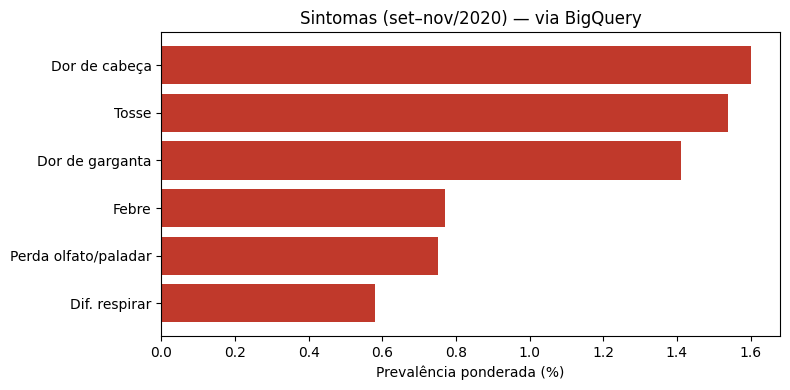

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,4))
ax.barh(prev['s'], prev['p'], color='#c0392b')
ax.set_xlabel('Prevalência ponderada (%)'); ax.set_title('Sintomas (set–nov/2020) — via BigQuery')
plt.tight_layout(); plt.show()

In [8]:
# Internação por faixa etária (B005 x A002) — risco por idade
consultar(f'''
SELECT faixa_etaria,
  ROUND(100*SAFE_DIVIDE(SUM(IF(internado='Sim',peso,0)),SUM(IF(internado IN('Sim','Não'),peso,0))),2) AS taxa_internacao
FROM `{tabela_id}` WHERE faixa_etaria IS NOT NULL
GROUP BY faixa_etaria ORDER BY faixa_etaria
''')

,faixa_etaria,taxa_internacao
0,0-12,10.06
1,13-19,4.96
2,20-39,6.93
3,40-59,9.13
4,60+,19.47


## 7 — Comportamento da população (SQL no BigQuery)

In [9]:
# Isolamento ao longo dos 3 meses (B011)
consultar(f'''
SELECT mes_nome, grau_isolamento, ROUND(SUM(peso)) AS pop
FROM `{tabela_id}` WHERE grau_isolamento IS NOT NULL
GROUP BY mes_nome, grau_isolamento ORDER BY mes_nome, grau_isolamento
''')

,mes_nome,grau_isolamento,pop
0,Novembro,Não fez restrição,5473614.0
1,Novembro,"Reduziu contato, mas saiu",205681784.0
2,Outubro,"Ficou em casa, só saiu p/ básico",80700142.0
3,Outubro,Ficou rigorosamente isolado,26278308.0
4,Outubro,Não fez restrição,9713129.0
5,Outubro,"Reduziu contato, mas saiu",93793962.0
6,Setembro,"Ficou em casa, só saiu p/ básico",85284797.0
7,Setembro,Ficou rigorosamente isolado,34501044.0
8,Setembro,Não fez restrição,6426465.0
9,Setembro,"Reduziu contato, mas saiu",84098977.0


In [10]:
# Testagem por escolaridade (B008 x A005)
consultar(f'''
SELECT escolaridade,
  ROUND(100*SAFE_DIVIDE(SUM(IF(fez_teste='Sim',peso,0)),SUM(IF(fez_teste IN('Sim','Não'),peso,0))),1) AS taxa_teste
FROM `{tabela_id}` WHERE escolaridade IS NOT NULL
GROUP BY escolaridade ORDER BY taxa_teste
''')

,escolaridade,taxa_teste
0,Sem instrução,4.6
1,Fundamental incompleto,6.6
2,Médio incompleto,8.9
3,Fundamental completo,9.5
4,Médio completo,13.6
5,Superior incompleto,17.5
6,Superior completo,22.0
7,Pós-graduação,27.6


## 8 — Características econômicas (SQL no BigQuery)
Auxílio emergencial (**D0051**) por posição na ocupação, e isolamento rigoroso por faixa de renda.

In [11]:
# Auxílio emergencial por posição na ocupação (D0051 x C007)
# Denominador = todos da ocupação (a D0051 tem ~33% de nulos: nulo/Não = "não recebeu").
consultar(f'''
SELECT posicao_ocupacao,
  ROUND(100*SAFE_DIVIDE(SUM(IF(auxilio_emergencial='Sim',peso,0)), SUM(peso)),1) AS pct_auxilio
FROM `{tabela_id}` WHERE posicao_ocupacao IS NOT NULL
GROUP BY posicao_ocupacao ORDER BY pct_auxilio DESC
''')

,posicao_ocupacao,pct_auxilio
0,Trab. familiar auxiliar,62.0
1,Doméstico,61.8
2,Conta própria,60.7
3,Setor privado,37.3
4,Ignorado,29.5
5,Setor público,21.7
6,Militar,20.7
7,Empregador,20.3
8,Policial/Bombeiro,12.7


In [12]:
# Isolamento rigoroso por faixa de renda (C01012 x B011) — SÓ OCUPADOS (rendimento > 0)
# As faixas de renda só existem para quem tem rendimento; restringir evita o confundidor
# de 'Sem renda' (não-ocupados que ficam em casa por não trabalhar).
consultar(f'''
WITH base AS (
  SELECT peso, grau_isolamento,
    CASE WHEN rendimento<=1045 THEN 'Até 1 SM' WHEN rendimento<=2090 THEN '1-2 SM'
         WHEN rendimento<=5225 THEN '2-5 SM' ELSE '5+ SM' END AS faixa_renda
  FROM `{tabela_id}` WHERE rendimento IS NOT NULL AND rendimento>0)
SELECT faixa_renda,
  ROUND(100*SAFE_DIVIDE(SUM(IF(grau_isolamento='Ficou rigorosamente isolado',peso,0)),SUM(peso)),1) AS pct_isolado_rigoroso
FROM base WHERE grau_isolamento IS NOT NULL
GROUP BY faixa_renda ORDER BY pct_isolado_rigoroso
''')

,faixa_renda,pct_isolado_rigoroso
0,Até 1 SM,0.9
1,1-2 SM,1.7
2,2-5 SM,2.0
3,5+ SM,2.8


## 9 — Ações ao hospital em caso de novo surto

A partir das análises acima (a leitura dos números reais é sua):

1. **Triagem por sintoma-marcador** — prioridade para dificuldade de respirar e perda de olfato/paladar.
2. **Leitos por faixa etária** — reserva proporcional ao risco, maior para idosos.
3. **Testagem dirigida** — mutirões onde a testagem é menor (baixa escolaridade/renda).
4. **Retaguarda do SUS** — dimensionar pela cobertura de plano de saúde.
5. **Gatilho de renda** — isolamento não se sustenta sem transferência de renda a informais.
6. **Vigilância contínua** — reaproveitar este pipeline para alertas por sintoma-marcador.

## 10 (opcional) — Liberar leitura do dataset
Permite que outras contas Google consultem a tabela (cada uma usa o próprio projeto para faturar a query).

In [13]:
# from carga_bigquery import tornar_publico
# tornar_publico(client, PROJECT, DATASET)